# Description

This notebook takes in raw geophysical data from Data/Tharsis AOI 1, gives it the right coordinate system and removes outliers. It does not sample the data. The end of the notebook returns the processed data and puts it in Data/Tharsis AOI 1.

# Packages

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from sklearn.neighbors import NearestNeighbors

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import HelperMethods

import threading
import os

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

trigger_create_cross_section = True

# Auxilary functions

In [ ]:
def remove_magnetic_outliers(data, n_neighbors=10, threshold_factor=3.0):
    """
    Remove magnetic data outliers based on nearest neighbors analysis
    
    Parameters:
    - data: GeoDataFrame with magnetic data
    - n_neighbors: number of nearest neighbors to consider
    - threshold_factor: multiplier for standard deviation threshold
    """
    # Extract coordinates and magnetic values
    coords = data[['VALU_COORX', 'VALU_COORY']].values
    mag_values = data['MAG'].values
    
    # Fit k-nearest neighbors model
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    
    # Calculate outlier scores for each point
    outlier_scores = []
    
    for i in range(len(data)):
        # Get indices of nearest neighbors (excluding the point itself)
        neighbor_indices = indices[i][1:]  # Skip first index (the point itself)
        
        # Get magnetic values of neighbors
        neighbor_mag_values = mag_values[neighbor_indices]
        
        # Calculate mean and std of neighbors
        neighbor_mean = np.mean(neighbor_mag_values)
        neighbor_std = np.std(neighbor_mag_values)
        
        # Calculate how many standard deviations the current point is from neighbor mean
        if neighbor_std > 0:
            outlier_score = abs(mag_values[i] - neighbor_mean) / neighbor_std
        else:
            outlier_score = 0
            
        outlier_scores.append(outlier_score)
    
    outlier_scores = np.array(outlier_scores)
    
    # Identify outliers
    outlier_mask = outlier_scores > threshold_factor
    
    # Create cleaned dataset
    cleaned_data = data[~outlier_mask].copy()
    removed_data = data[outlier_mask].copy()
    
    print(f"Original data points: {len(data)}")
    print(f"Outliers detected: {np.sum(outlier_mask)}")
    print(f"Cleaned data points: {len(cleaned_data)}")
    print(f"Percentage removed: {(np.sum(outlier_mask)/len(data)*100):.2f}%")
    
    if len(removed_data) > 0:
        print(f"Outlier magnetic range: {removed_data['MAG'].min():.2f} to {removed_data['MAG'].max():.2f} nT")
        print(f"Cleaned magnetic range: {cleaned_data['MAG'].min():.2f} to {cleaned_data['MAG'].max():.2f} nT")
    
    return cleaned_data, removed_data, outlier_scores

# Model Parameters

In [ ]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Loading in Geophysical Data

In [ ]:
# Load and plot the geophysical gravity data and convert to right coordinate system
gravity_data = gpd.read_file(os.path.join(data_dir, 'AOI1_GF_Gravity_cropped_EPSG23030.geojson'))
gravity_data = gravity_data.to_crs(epsg=3857)

gravity_data['VALU_COORX'] = gravity_data.geometry.x
gravity_data['VALU_COORY'] = gravity_data.geometry.y

# Clip data to model bounds
gravity_data = gravity_data.cx[min_x:max_x, min_y:max_y]

# Load and plot the geophysical gravity data and convert to right coordinate system
magnetic_data = gpd.read_file(os.path.join(data_dir, 'AOI1_airborneMagnetics_EPSG23030.geojson'))
magnetic_data = magnetic_data.to_crs(epsg=3857)

# Extract coordinates
magnetic_data['VALU_COORX'] = magnetic_data.geometry.x
magnetic_data['VALU_COORY'] = magnetic_data.geometry.y

# Clip data to model bounds
magnetic_data = magnetic_data.cx[min_x:max_x, min_y:max_y]

# Pre-Processing Geophysical Data

Gravity data loaded successfully!
Data shape: (260, 8)
Columns: ['ID', 'VALU_COORX', 'VALU_COORY', 'CODE_H50', 'CODE_DOCU', 'VALU_BOU267', 'ESRI_OID', 'geometry']
Gravity range: 9.51 to 47.32 mGal


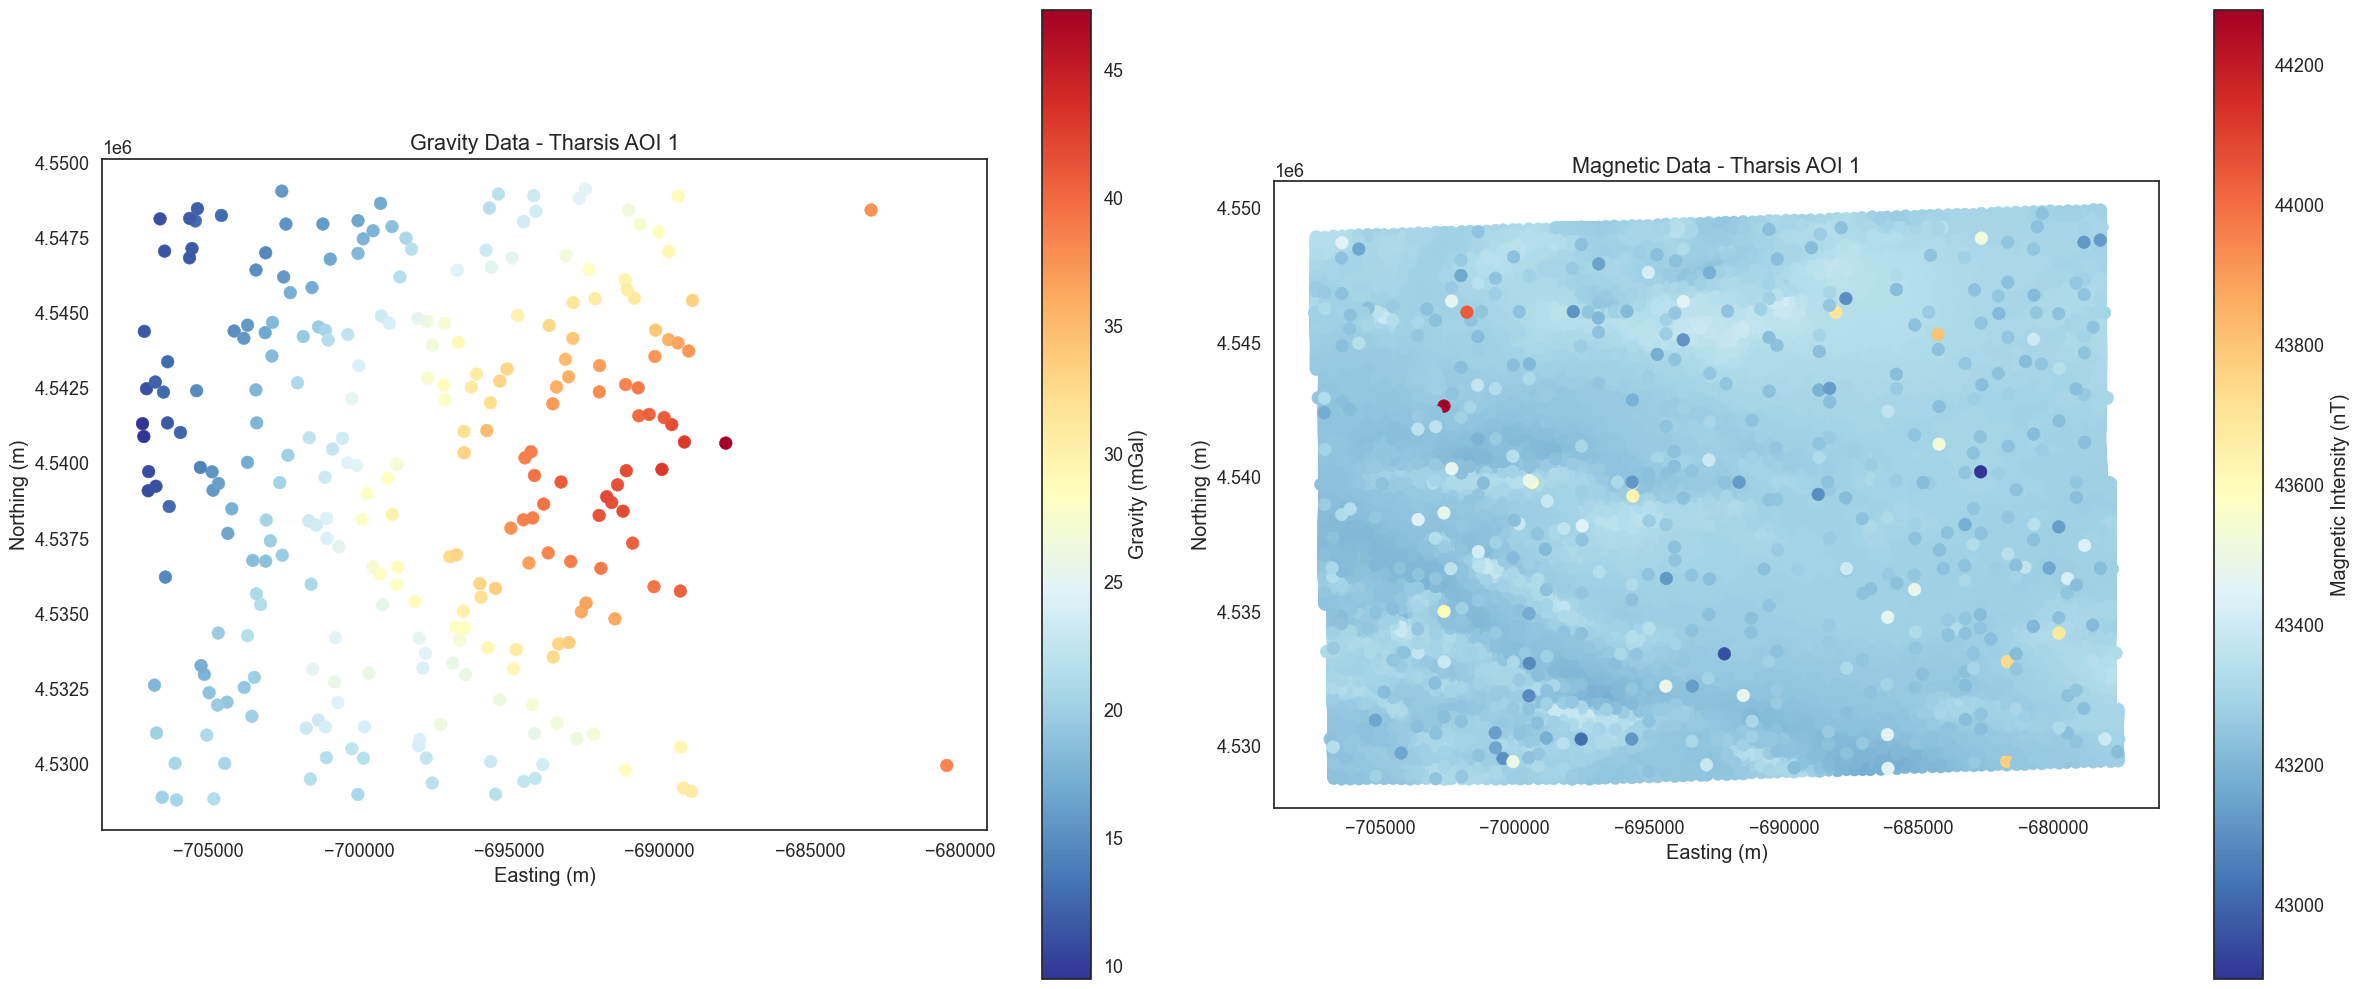

Magnetic data loaded successfully!
Data shape: (54261, 18)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry', 'VALU_COORX', 'VALU_COORY']
Magnetic range: 42894.50 to 44278.60 nT


In [ ]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Plot the gravity data
gravity_plot = gravity_data.plot(
    column='VALU_BOU267', 
    ax=ax1, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Gravity (mGal)', 'orientation': 'vertical'}
)

ax1.set_title('Gravity Data - Tharsis AOI 1')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.set_aspect('equal')

print(f"Gravity data loaded successfully!")
print(f"Data shape: {gravity_data.shape}")
print(f"Columns: {gravity_data.columns.tolist()}")
print(f"Gravity range: {gravity_data['VALU_BOU267'].min():.2f} to {gravity_data['VALU_BOU267'].max():.2f} mGal")

# Plot the magnetic data
magnetic_plot = magnetic_data.plot(
    column='MAG', 
    ax=ax2, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax2.set_title('Magnetic Data - Tharsis AOI 1')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {magnetic_data.shape}")
print(f"Columns: {magnetic_data.columns.tolist()}")
print(f"Magnetic range: {magnetic_data['MAG'].min():.2f} to {magnetic_data['MAG'].max():.2f} nT")


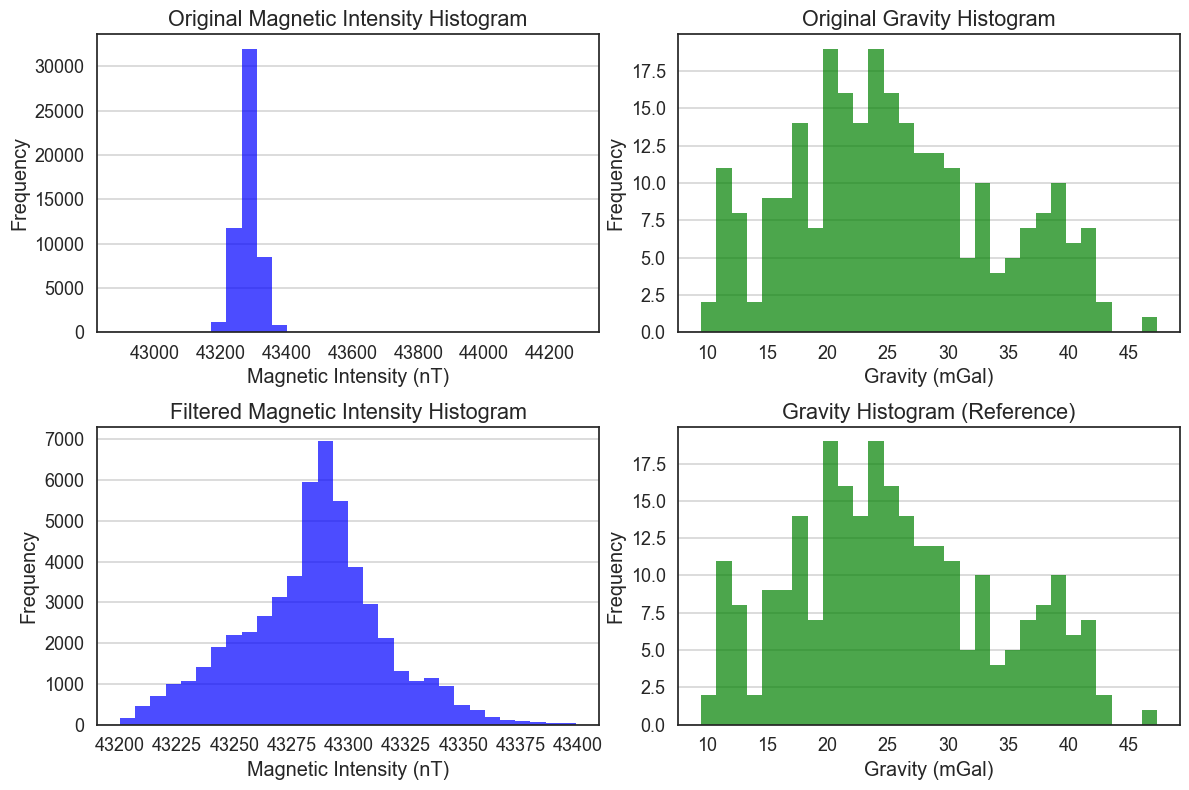

Original magnetic data shape: (54261, 18)
Filtered magnetic data shape: (53987, 18)
Magnetic range (original): 42894.50 to 44278.60 nT
Magnetic range (filtered): 43200.00 to 43399.20 nT


In [ ]:
# Create a figure with 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# First row - Original histograms
# Original magnetic histogram
ax1.hist(magnetic_data['MAG'], bins=30, color='blue', alpha=0.7)
ax1.set_title('Original Magnetic Intensity Histogram')
ax1.set_xlabel('Magnetic Intensity (nT)')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.75)

# Original gravity histogram
ax2.hist(gravity_data['VALU_BOU267'], bins=30, color='green', alpha=0.7)
ax2.set_title('Original Gravity Histogram')
ax2.set_xlabel('Gravity (mGal)')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', alpha=0.75)

# Filter magnetic data (remove outliers below 43200 and above 43400)
filtered_magnetic = magnetic_data[
    (magnetic_data['MAG'] >= 43200) &
    (magnetic_data['MAG'] <= 43400)
].copy()

# Second row - Modified histograms
# Filtered magnetic histogram
ax3.hist(filtered_magnetic['MAG'], bins=30, color='blue', alpha=0.7)
ax3.set_title('Filtered Magnetic Intensity Histogram')
ax3.set_xlabel('Magnetic Intensity (nT)')
ax3.set_ylabel('Frequency')
ax3.grid(axis='y', alpha=0.75)

# Gravity histogram (same as original for comparison)
ax4.hist(gravity_data['VALU_BOU267'], bins=30, color='green', alpha=0.7)
ax4.set_title('Gravity Histogram (Reference)')
ax4.set_xlabel('Gravity (mGal)')
ax4.set_ylabel('Frequency')
ax4.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

print(f"Original magnetic data shape: {magnetic_data.shape}")
print(f"Filtered magnetic data shape: {filtered_magnetic.shape}")
print(f"Magnetic range (original): {magnetic_data['MAG'].min():.2f} to {magnetic_data['MAG'].max():.2f} nT")
print(f"Magnetic range (filtered): {filtered_magnetic['MAG'].min():.2f} to {filtered_magnetic['MAG'].max():.2f} nT")

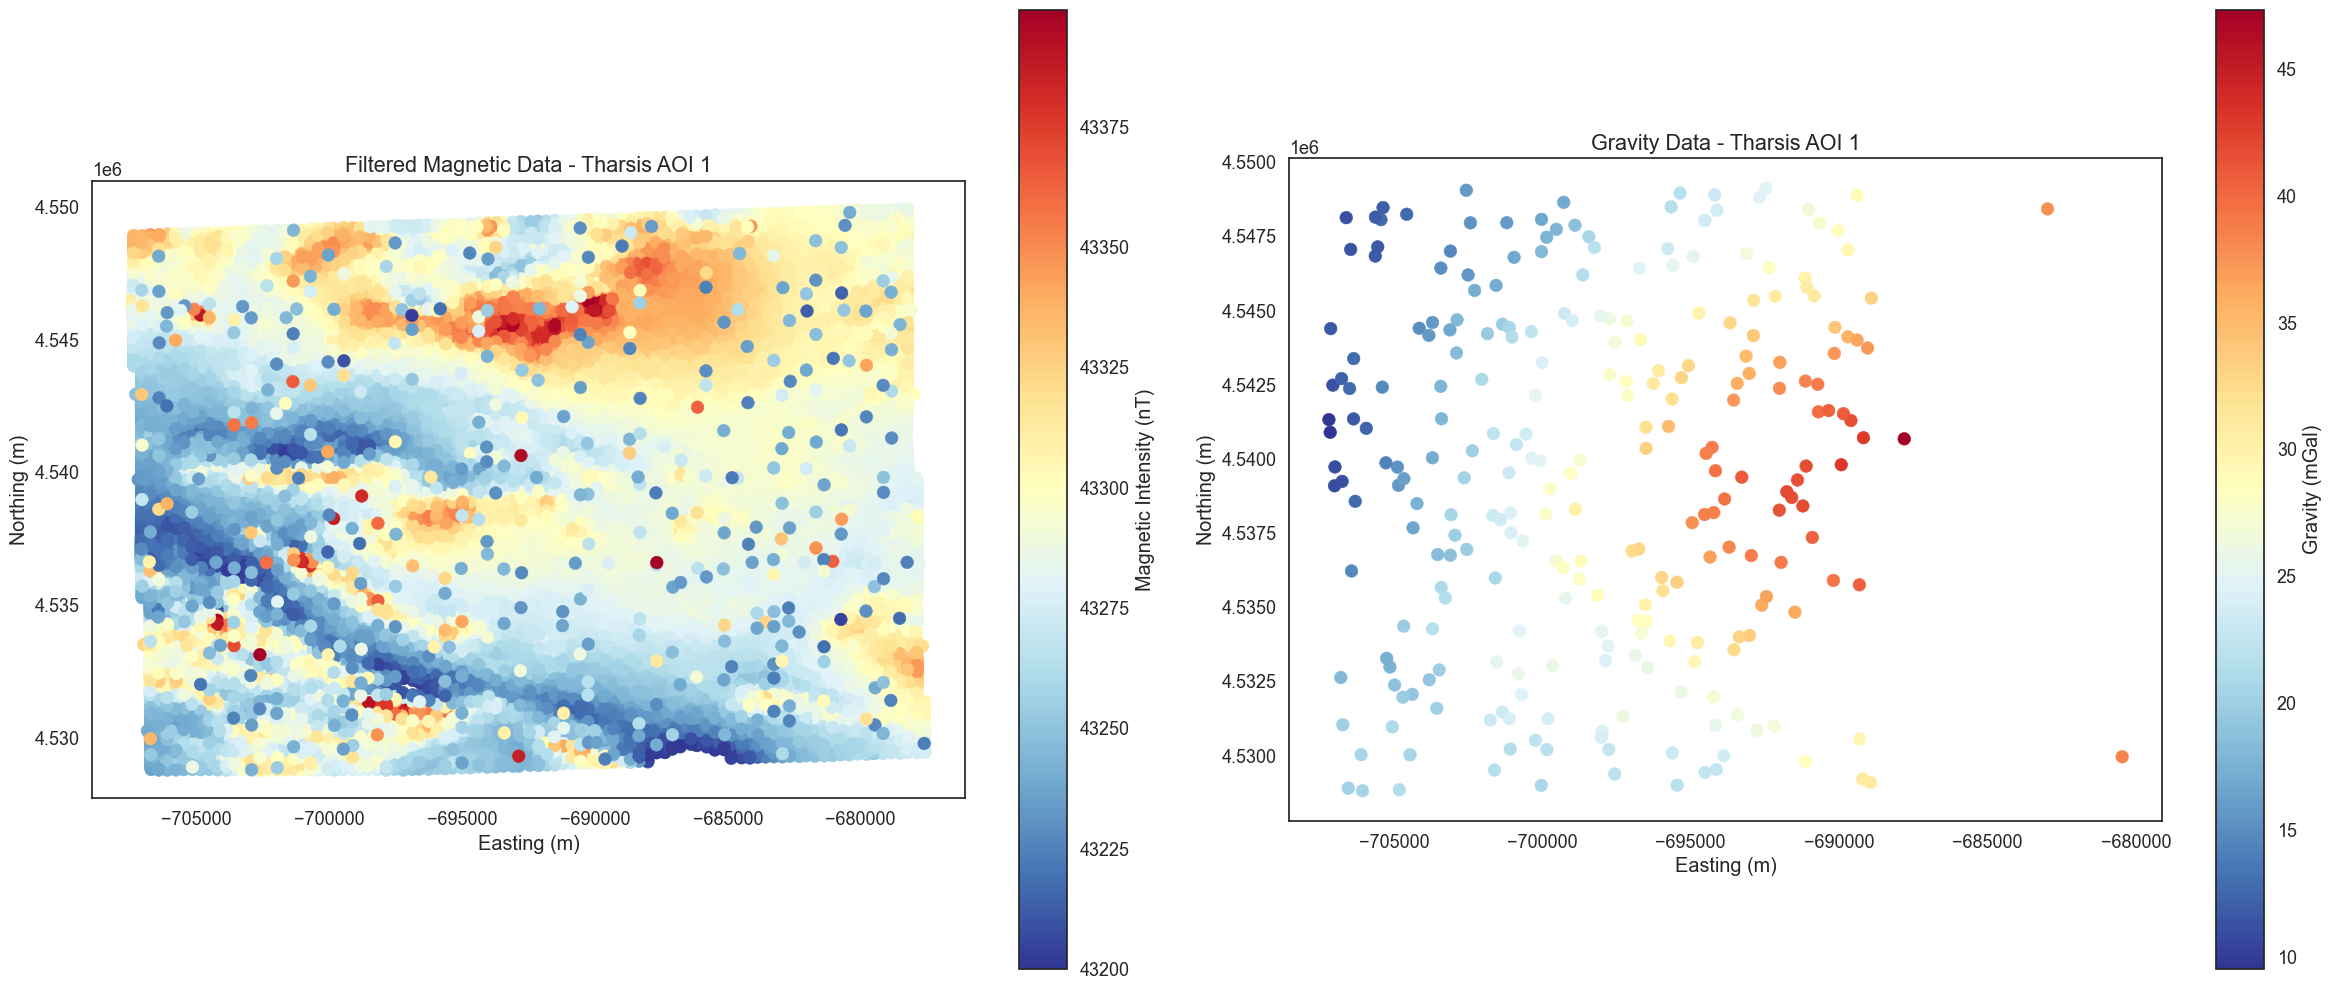

Magnetic data loaded successfully!
Data shape: (53987, 18)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry', 'VALU_COORX', 'VALU_COORY']
Magnetic range: 43200.00 to 43399.20 nT


In [ ]:
# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Plot the filtered magnetic data
filtered_magnetic.plot(
    column='MAG', 
    ax=ax1, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax1.set_title('Filtered Magnetic Data - Tharsis AOI 1')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.set_aspect('equal')

# Plot the gravity data
gravity_data.plot(
    column='VALU_BOU267', 
    ax=ax2, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Gravity (mGal)', 'orientation': 'vertical'}
)

ax2.set_title('Gravity Data - Tharsis AOI 1')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {filtered_magnetic.shape}")
print(f"Columns: {filtered_magnetic.columns.tolist()}")
print(f"Magnetic range: {filtered_magnetic['MAG'].min():.2f} to {filtered_magnetic['MAG'].max():.2f} nT")

In [ ]:
# Apply outlier removal to filtered magnetic data
cleaned_magnetic, removed_outliers, outlier_scores = remove_magnetic_outliers(
    filtered_magnetic, 
    n_neighbors=10, 
    threshold_factor=3.0
)

Original data points: 53987
Outliers detected: 373
Cleaned data points: 53614
Percentage removed: 0.69%
Outlier magnetic range: 43200.10 to 43398.00 nT
Cleaned magnetic range: 43200.00 to 43399.20 nT


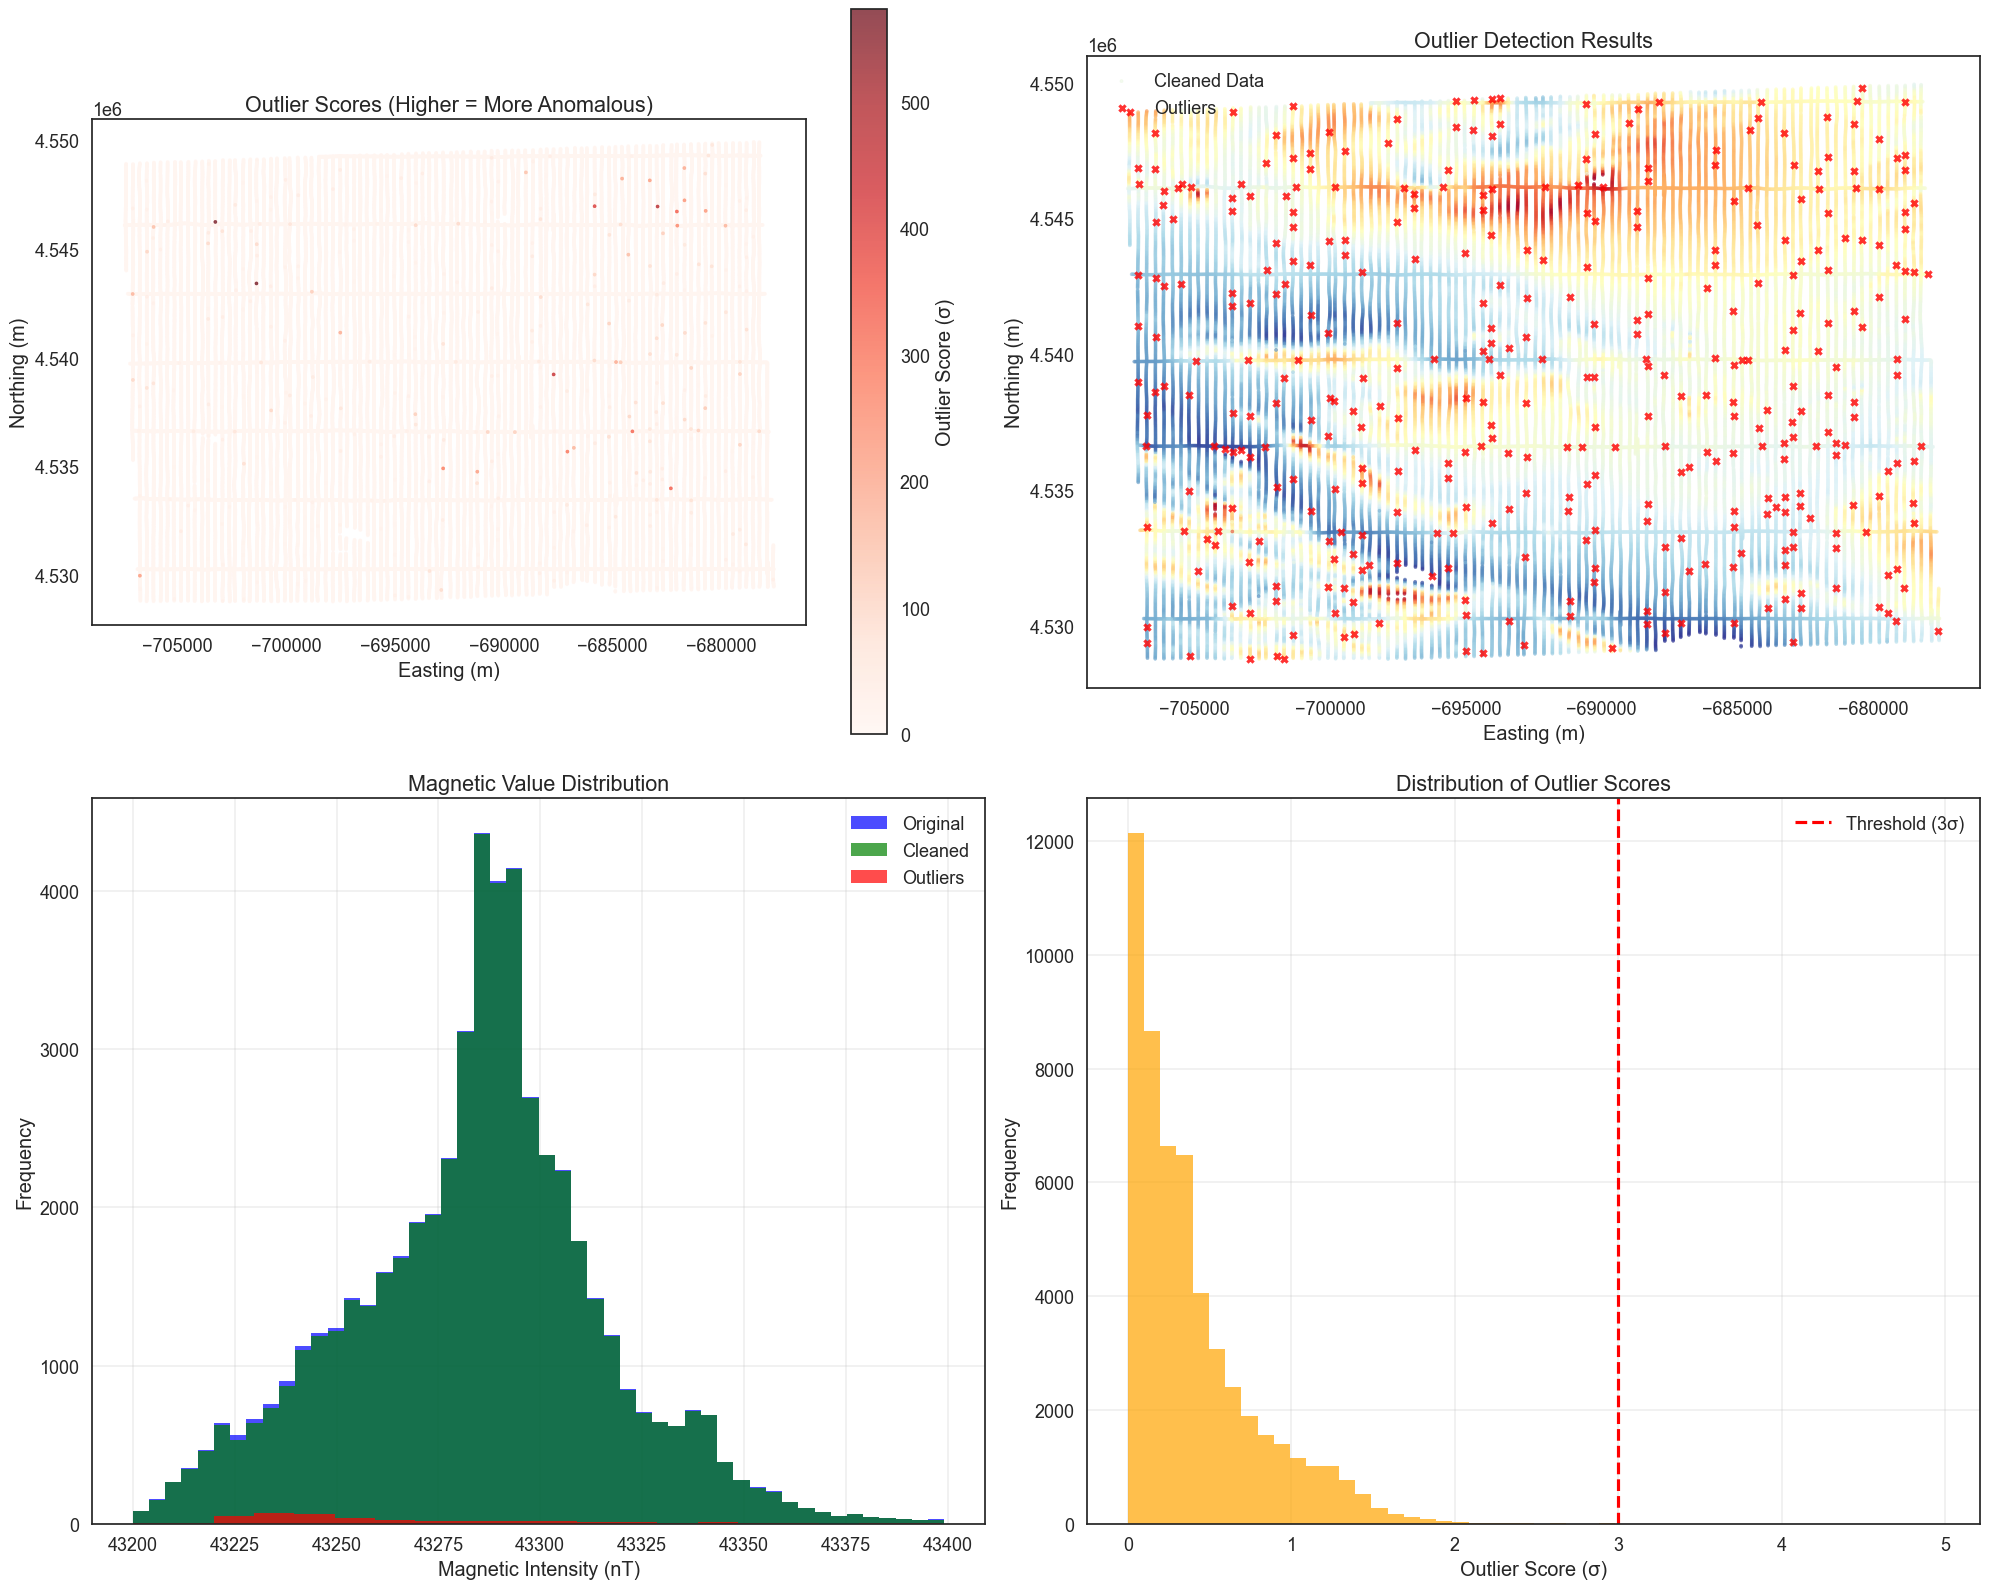

In [ ]:
# Create visualization showing outlier detection results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Original data with outlier scores
scatter1 = ax1.scatter(
    filtered_magnetic['VALU_COORX'], 
    filtered_magnetic['VALU_COORY'], 
    c=outlier_scores, 
    cmap='Reds', 
    s=5, 
    alpha=0.7
)
ax1.set_title('Outlier Scores (Higher = More Anomalous)')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.set_aspect('equal')
plt.colorbar(scatter1, ax=ax1, label='Outlier Score (σ)')

# Plot 2: Outliers highlighted
ax2.scatter(
    cleaned_magnetic['VALU_COORX'], 
    cleaned_magnetic['VALU_COORY'], 
    c=cleaned_magnetic['MAG'], 
    cmap='RdYlBu_r', 
    s=5, 
    alpha=0.6,
    label='Cleaned Data'
)
if len(removed_outliers) > 0:
    ax2.scatter(
        removed_outliers['VALU_COORX'], 
        removed_outliers['VALU_COORY'], 
        c='red', 
        s=20, 
        alpha=0.8,
        marker='x',
        label='Outliers'
    )
ax2.set_title('Outlier Detection Results')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')
ax2.legend()

# Plot 3: Histogram comparison
ax3.hist(filtered_magnetic['MAG'], bins=50, alpha=0.7, label='Original', color='blue')
ax3.hist(cleaned_magnetic['MAG'], bins=50, alpha=0.7, label='Cleaned', color='green')
if len(removed_outliers) > 0:
    ax3.hist(removed_outliers['MAG'], bins=20, alpha=0.7, label='Outliers', color='red')
ax3.set_xlabel('Magnetic Intensity (nT)')
ax3.set_ylabel('Frequency')
ax3.set_title('Magnetic Value Distribution')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Outlier score distribution
ax4.hist(outlier_scores[outlier_scores < 5], bins=50, alpha=0.7, color='orange')
ax4.axvline(x=3.0, color='red', linestyle='--', label='Threshold (3σ)')
ax4.set_xlabel('Outlier Score (σ)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Outlier Scores')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Update the filtered_magnetic variable with cleaned data
filtered_magnetic = cleaned_magnetic.copy()

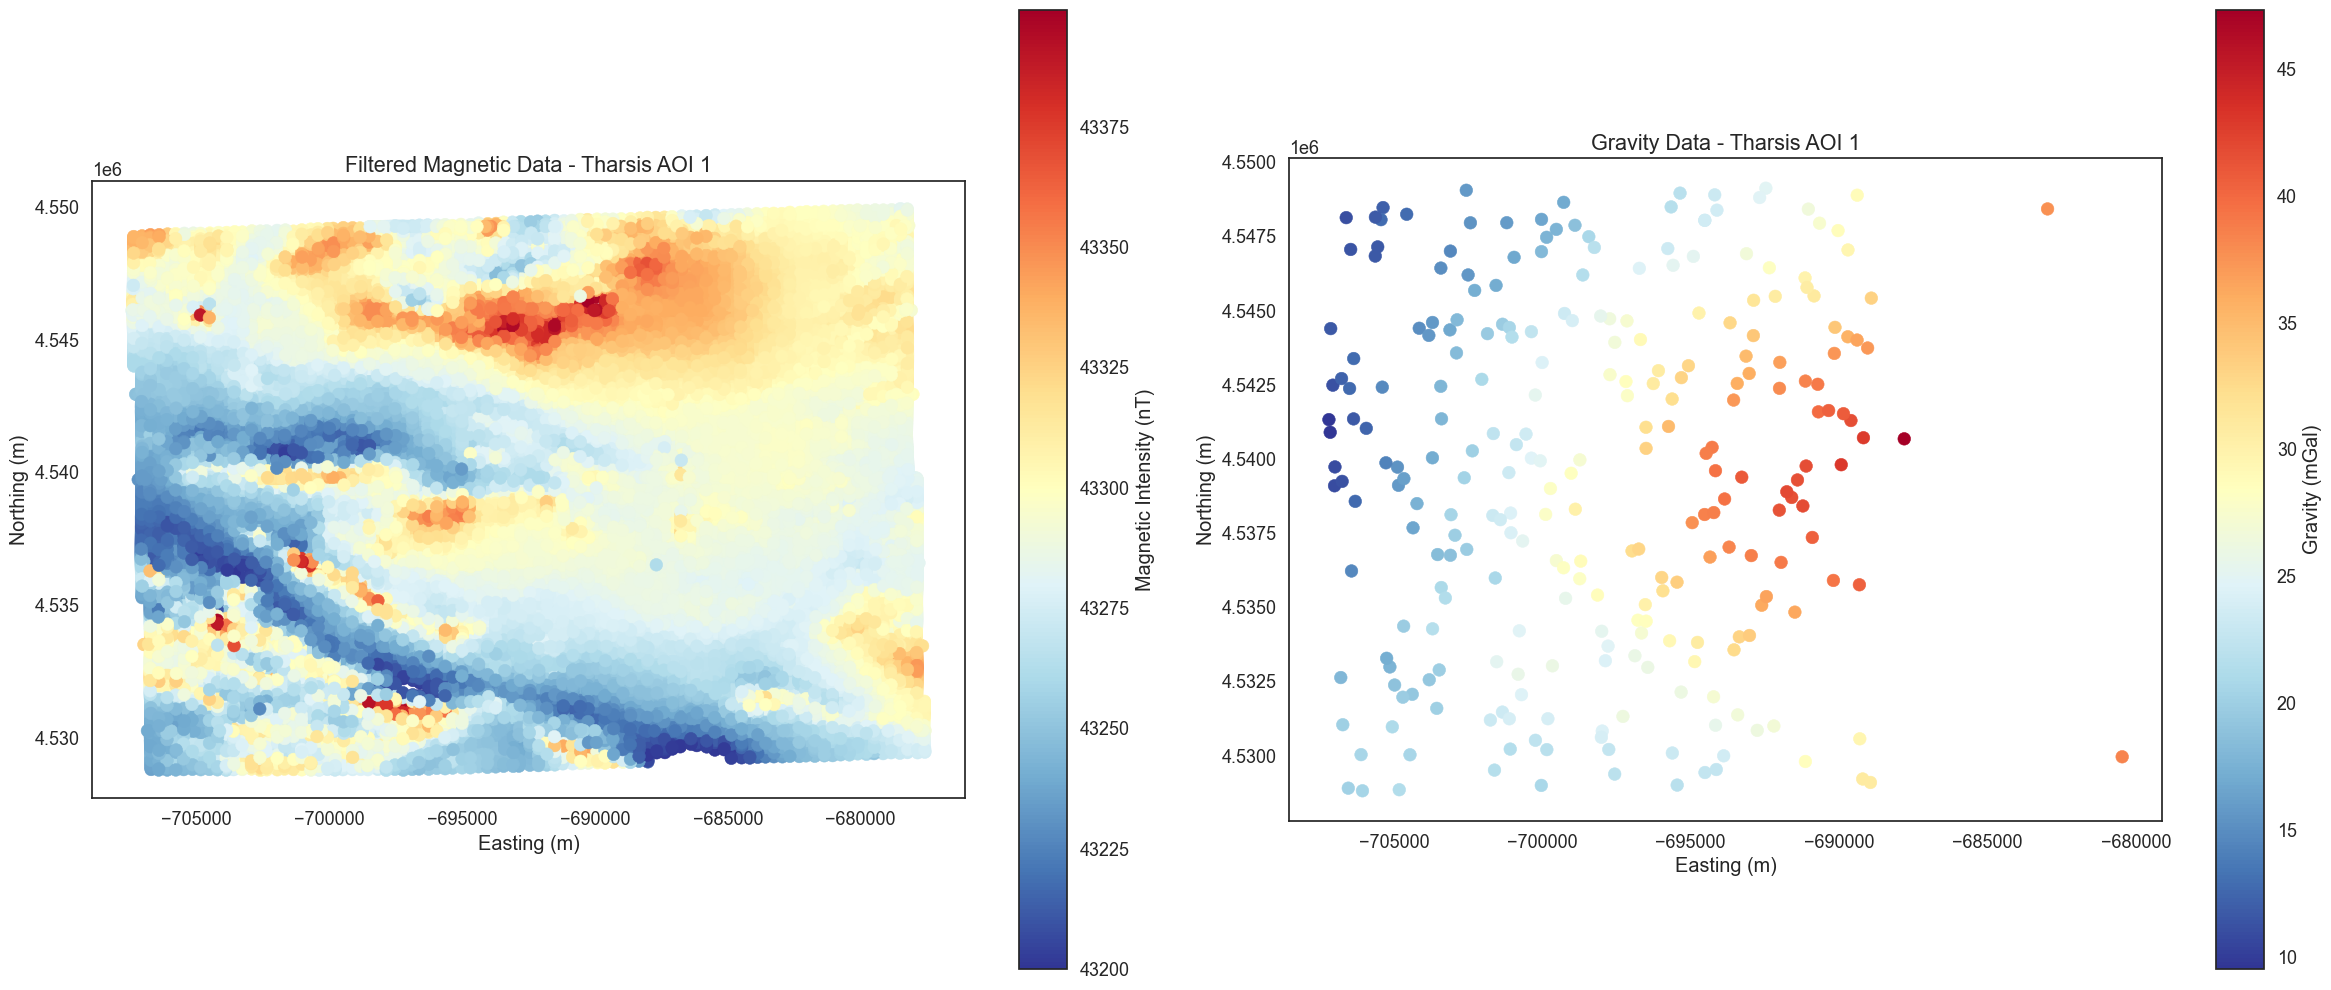

Magnetic data loaded successfully!
Data shape: (53614, 18)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry', 'VALU_COORX', 'VALU_COORY']
Magnetic range: 43200.00 to 43399.20 nT


In [ ]:
# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Plot the filtered magnetic data
filtered_magnetic.plot(
    column='MAG', 
    ax=ax1, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax1.set_title('Filtered Magnetic Data - Tharsis AOI 1')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.set_aspect('equal')

# Plot the gravity data
gravity_data.plot(
    column='VALU_BOU267', 
    ax=ax2, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Gravity (mGal)', 'orientation': 'vertical'}
)

ax2.set_title('Gravity Data - Tharsis AOI 1')
ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {filtered_magnetic.shape}")
print(f"Columns: {filtered_magnetic.columns.tolist()}")
print(f"Magnetic range: {filtered_magnetic['MAG'].min():.2f} to {filtered_magnetic['MAG'].max():.2f} nT")

# Correction for Measuring Height?

In [ ]:
# Maybe.. Maybe not???

# Safe Cleaned Geophysics Data

In [ ]:
# Save filtered data as geopandas geodataframes

filtered_magnetic.to_file(os.path.join(data_dir, 'cleaned_magnetic_data.geojson'), driver='GeoJSON')
gravity_data.to_file(os.path.join(data_dir, 'cleaned_gravity_data.geojson'), driver='GeoJSON')